# Predicting Type 2 Diabetes Onset with an LSTM on Longitudinal EHR Data

**Veda Sripada** · NYU Langone Health, Center for the Study of Asian American Health

Asian American adults develop type 2 diabetes at lower BMI than other groups, and risk differs widely across Asian ethnic subgroups. Screening rules built on BMI cutoffs miss many of them. This notebook trains a sequence model on routine office-visit vitals to ask two questions:

1. **Can we identify who will develop diabetes** from blood pressure, BMI, visit timing and baseline covariates alone?
2. **How early?** For patients who convert, how many days before the recorded diagnosis does the model first flag them (*lead time*), and does that differ by Asian subgroup?

**Pipeline**

| Step | What happens |
|---|---|
| Cohort | Adults with ≥1 office visit, no diabetes in the lookback window ([`r/01_data_prep.Rmd`](../r/01_data_prep.Rmd)) |
| Imputation | Multilevel MICE (`2l.norm`, patient as cluster) for BMI/SBP/DBP, **outcome variables excluded** from the imputation model |
| Sequences | One sequence per patient, truncated at the diagnosis visit, padded and masked |
| Model | LSTM over visit vitals + dense encoder for static covariates → per-visit sigmoid |
| Evaluation | Patient-level ROC/PR on a held-out test set, threshold chosen on validation only |
| Lead time | Days between first positive flag and diagnosis, overall and by subgroup |
| Explainability | Permutation importance (drop in patient-level ROC-AUC) |

> The EHR extract is protected health information and is not included in this repository. All outputs shown are aggregate.

In [1]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    auc, average_precision_score, confusion_matrix, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# ---- Configuration -------------------------------------------------------
DATA_PATH = os.environ["DATA_PATH"]   # imputed EHR extract from r/01_data_prep.Rmd (not included)
FIG_DIR = Path("../figures")
RESULTS_DIR = Path("../results")
SEED = 42
MIN_CELL = 11          # suppress any subgroup count below this in published outputs

FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ---- Plot style ----------------------------------------------------------
INK, TERRACOTTA, OLIVE, MUSTARD, TEAK, STONE = "#1c1c1c", "#c35237", "#606e4c", "#e1ad01", "#5c4033", "#f4f1ea"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": INK, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK, "font.size": 10, "figure.dpi": 110,
    "axes.prop_cycle": plt.cycler(color=[INK, TERRACOTTA, OLIVE, MUSTARD, TEAK]),
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=160, bbox_inches="tight")

## 1. Load data and define the cohort

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)

def to_datetime(col):
    # surv_no_pheno is stored as an Excel-style serial day number; contact_date as ISO text
    if pd.api.types.is_numeric_dtype(col):
        return pd.to_datetime(col.astype(float), unit="D", origin="1899-12-30")
    return pd.to_datetime(col, errors="coerce")

df["contact_date"] = to_datetime(df["contact_date"])
df["diag_date"] = to_datetime(df["surv_no_pheno"])
df = df.sort_values(["pat_id", "contact_date"]).reset_index(drop=True)

SUBGROUP_MAP = {
    "Chinese": "Chinese", "Filipino": "Filipino", "Vietnamese": "Vietnamese",
    "Korean": "Korean", "Japanese": "Japanese",
    "Asian Indian": "South Asian", "Pakistani": "South Asian", "Bangladeshi": "South Asian",
    "Sri Lankan": "South Asian", "Nepali": "South Asian",
}
df["asian_subgroup"] = df["asian_ethnic_group"].map(SUBGROUP_MAP).fillna("Other Asian")

patients = df.groupby("pat_id").agg(
    converted=("diabetes_onset", "first"),
    n_visits=("contact_date", "size"),
    subgroup=("asian_subgroup", "first"),
)
print(f"Patients: {len(patients):,}   Visits: {len(df):,}   "
      f"Converters: {patients.converted.sum():,} ({patients.converted.mean():.1%})")

Patients: 4,225   Visits: 39,678   Converters: 218 (5.2%)


### Rebuilding the visit-level label

The upstream extract marks `diabetes_diag_at_visit = 1` on the **first** visit of every converter, because `diabetes_onset` is constant within a patient. Here the label is rebuilt from the diagnosis date: the positive visit is the first visit on or after `surv_no_pheno` (or the last visit if follow-up ends first), and **visits after diagnosis are dropped** so the model never sees post-diagnosis data.

In [3]:
visit_no = df.groupby("pat_id").cumcount()
last_visit = df.groupby("pat_id")["contact_date"].transform("size") - 1
first_on_or_after = (visit_no.where(df["contact_date"] >= df["diag_date"])
                     .groupby(df["pat_id"]).transform("min"))
diag_visit = first_on_or_after.fillna(last_visit)
converter = df["diabetes_onset"] == 1

df = df[~converter | (visit_no <= diag_visit)].copy()
df["label"] = (converter & (visit_no == diag_visit)).loc[df.index].astype(int)
print(f"Visits after truncation: {len(df):,}   Positive visits: {df.label.sum():,}")

Visits after truncation: 39,678   Positive visits: 218


### Cohort overview

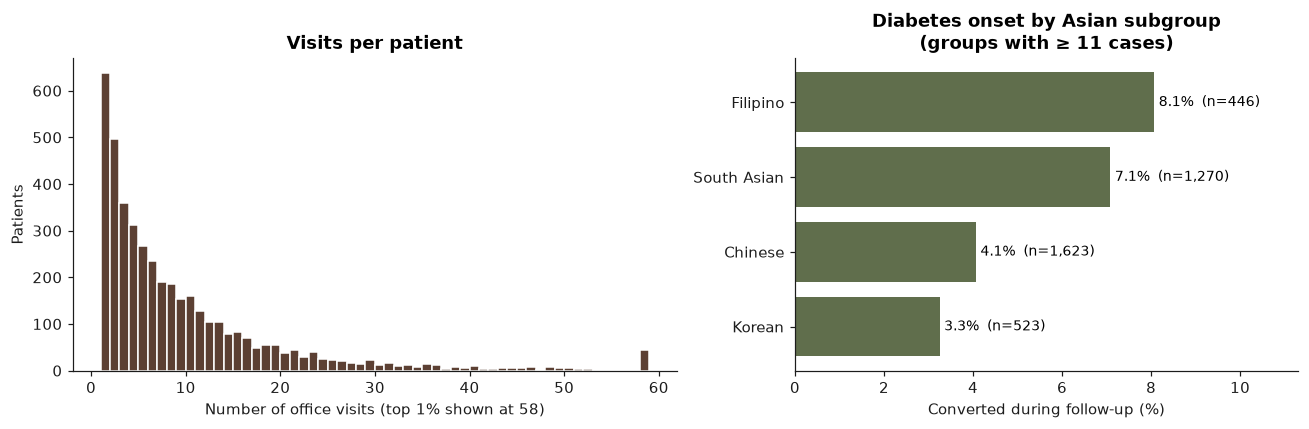

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.2, 1]})

cap = int(patients.n_visits.quantile(0.99))
axes[0].hist(patients.n_visits.clip(upper=cap), bins=range(1, cap + 2), color=TEAK, edgecolor="white")
axes[0].set(title="Visits per patient", xlabel=f"Number of office visits (top 1% shown at {cap})",
            ylabel="Patients")

prev = (patients.groupby("subgroup")
        .agg(n=("converted", "size"), cases=("converted", "sum"), rate=("converted", "mean"))
        .query("cases >= @MIN_CELL").sort_values("rate"))
axes[1].barh(prev.index, prev.rate * 100, color=OLIVE)
for y, (rate, n) in enumerate(zip(prev.rate, prev.n)):
    axes[1].text(rate * 100 + 0.1, y, f"{rate:.1%}  (n={n:,})", va="center", fontsize=9)
axes[1].set(title=f"Diabetes onset by Asian subgroup\n(groups with ≥ {MIN_CELL} cases)",
            xlabel="Converted during follow-up (%)")
axes[1].set_xlim(0, prev.rate.max() * 140)

fig.tight_layout(); save(fig, "cohort_overview"); plt.show()

## 2. Build sequences

* **Patient-level split** (60 / 15 / 25), stratified on conversion, so no patient appears in more than one set.
* **Scalers are fit on the training set only.**
* `time_since_last_visit` is log-transformed (heavily right-skewed).
* Subgroup is **one-hot encoded** rather than given an arbitrary integer code.
* Sequences are padded with `PAD = -999`, the same value the `Masking` layer ignores, and padded steps get sample weight 0.

In [5]:
DYNAMIC = ["time_since_last_visit", "bp_systolic_new", "bp_diastolic_new", "bmi_new"]
STATIC_NUM = ["age_years"]
STATIC_BIN = [
    "privins_lookback", "hld_phenotype_lookback", "hypertens_lookback", "ischhd_lookback",
    "cerebrvasd_lookback", "heartfail_lookback", "perivd_lookback", "renald_lookback",
    "alcohol_lookback", "tobacco_ever_lookback",
]
SUBGROUPS = sorted(df["asian_subgroup"].unique())
PAD = -999.0

ids = patients.index.to_numpy()
y_pat = patients["converted"].to_numpy()
ids_trval, ids_test = train_test_split(ids, test_size=0.25, stratify=y_pat, random_state=SEED)
ids_train, ids_val = train_test_split(
    ids_trval, test_size=0.2, stratify=patients.loc[ids_trval, "converted"], random_state=SEED)

df["time_since_last_visit"] = np.log1p(df["time_since_last_visit"].clip(lower=0))
train_rows = df[df.pat_id.isin(ids_train)]
dyn_mean, dyn_std = train_rows[DYNAMIC].mean(), train_rows[DYNAMIC].std()
first_train = train_rows.groupby("pat_id").first()
age_mean, age_std = first_train["age_years"].mean(), first_train["age_years"].std()

grouped = {pid: g for pid, g in df.groupby("pat_id")}
MAX_LEN = int(df.groupby("pat_id").size().max())

def static_vector(row):
    age = (row["age_years"] - age_mean) / age_std
    sex = float(row["sex"] in ("Male", "M", 1))
    onehot = [float(row["asian_subgroup"] == s) for s in SUBGROUPS]
    return [age, sex, *row[STATIC_BIN].astype(float), *onehot]

STATIC_NAMES = ["age_years", "sex", *STATIC_BIN, *[f"subgroup_{s}" for s in SUBGROUPS]]

def build(pids):
    n = len(pids)
    X_dyn = np.full((n, MAX_LEN, len(DYNAMIC)), PAD, dtype="float32")
    y = np.zeros((n, MAX_LEN), dtype="float32")
    valid = np.zeros((n, MAX_LEN), dtype=bool)
    X_stat, dates, diag = [], [], []
    for i, pid in enumerate(pids):
        g = grouped[pid]
        T = len(g)
        X_dyn[i, :T] = ((g[DYNAMIC] - dyn_mean) / dyn_std).to_numpy()
        y[i, :T] = g["label"].to_numpy()
        valid[i, :T] = True
        X_stat.append(static_vector(g.iloc[0]))
        dates.append(g["contact_date"].to_numpy())
        diag.append(g["diag_date"].iat[0])
    return dict(ids=np.asarray(pids), X_dyn=X_dyn, X_stat=np.asarray(X_stat, "float32"),
                y=y, valid=valid, y_pat=y.max(axis=1).astype(int), dates=dates, diag=diag)

train, val, test = build(ids_train), build(ids_val), build(ids_test)
for name, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}  patients={len(s['ids']):5,}  converters={s['y_pat'].sum():4,}  "
          f"visits={s['valid'].sum():7,}")

train  patients=2,534  converters= 130  visits= 24,419
val    patients=  634  converters=  33  visits=  5,805
test   patients=1,057  converters=  55  visits=  9,454


## 3. Model

Two input branches: an LSTM reads the masked visit sequence, and a small dense layer encodes the static covariates, which are repeated across time steps. The two are concatenated and a time-distributed sigmoid outputs the probability that diagnosis is recorded at each visit.

Positives are rare (≈1 positive visit per converter), so training uses two remedies: converters are oversampled to 50% of non-converters, and positive visits get a capped weight of 2×. The model trains with early stopping on validation PR-AUC.

In [6]:
class ClearMask(layers.Layer):
    # Drop the mask after the LSTM so it can be concatenated with the unmasked static branch
    def compute_mask(self, inputs, mask=None):
        return None
    def call(self, inputs):
        return inputs

def build_model(seq_len, n_dyn, n_stat, units=64):
    dyn_in = layers.Input((seq_len, n_dyn), name="visits")
    stat_in = layers.Input((n_stat,), name="static")
    x = layers.Masking(mask_value=PAD)(dyn_in)
    x = layers.LSTM(units, return_sequences=True)(x)
    x = ClearMask()(x)
    s = layers.Dense(32, activation="relu")(stat_in)
    s = layers.RepeatVector(seq_len)(s)
    h = layers.Concatenate()([x, s])
    h = layers.Dropout(0.3)(h)
    out = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"), name="visit_risk")(h)
    model = Model([dyn_in, stat_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                  weighted_metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
    return model

def sample_weights(s, pos_weight=2.0):
    return np.where(s["y"] == 1, pos_weight, 1.0) * s["valid"]

def oversample(s, ratio=0.5, seed=SEED):
    pos, neg = np.flatnonzero(s["y_pat"] == 1), np.flatnonzero(s["y_pat"] == 0)
    n_pos = max(len(pos), int(len(neg) * ratio))
    idx = np.concatenate([neg, np.random.default_rng(seed).choice(pos, n_pos, replace=True)])
    return np.random.default_rng(seed).permutation(idx)

model = build_model(MAX_LEN, len(DYNAMIC), train["X_stat"].shape[1])
model.summary()

idx = oversample(train)
history = model.fit(
    [train["X_dyn"][idx], train["X_stat"][idx]], train["y"][idx, :, None],
    sample_weight=sample_weights(train)[idx],
    validation_data=([val["X_dyn"], val["X_stat"]], val["y"][..., None], sample_weights(val)),
    epochs=60, batch_size=64, verbose=0,
    callbacks=[EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True)],
)
print(f"Stopped after {len(history.history['loss'])} epochs; "
      f"best val PR-AUC {max(history.history['val_pr_auc']):.3f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ visits (InputLayer) │ (None, 155, 4)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 155, 4)    │          0 │ visits[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 155, 4)    │          0 │ visits[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 155)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static (InputLayer) │ (None, 19)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 155, 64)   │     17,664 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        640 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clear_mask          │ (None, 155, 64)   │          0 │ lstm[0][0]        │
│ (ClearMask)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 155, 32)   │          0 │ dense[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 155, 96)   │          0 │ clear_mask[0][0], │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 155, 96)   │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visit_risk          │ (None, 155, 1)    │         97 │ dropout[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,401 (71.88 KB)

 Trainable params: 18,401 (71.88 KB)

 Non-trainable params: 0 (0.00 B)

Stopped after 17 epochs; best val PR-AUC 0.061


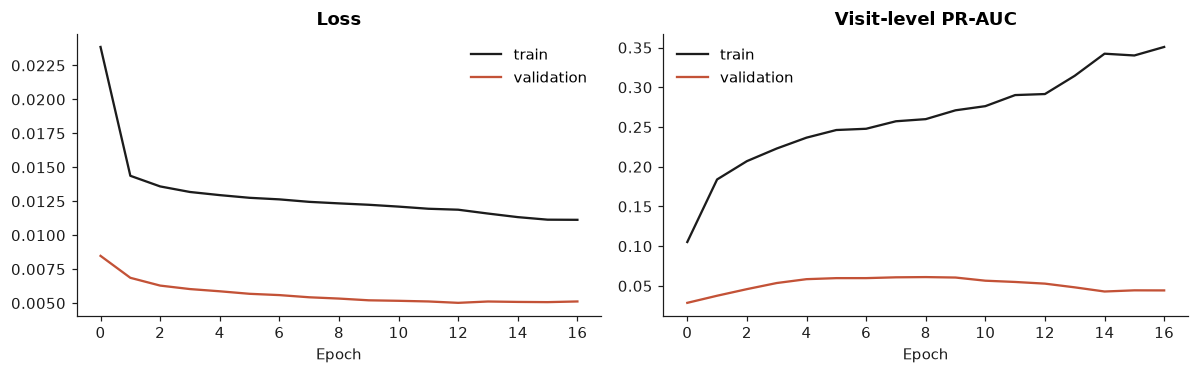

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history.history["loss"], color=INK, label="train")
axes[0].plot(history.history["val_loss"], color=TERRACOTTA, label="validation")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(frameon=False)
axes[1].plot(history.history["pr_auc"], color=INK, label="train")
axes[1].plot(history.history["val_pr_auc"], color=TERRACOTTA, label="validation")
axes[1].set(title="Visit-level PR-AUC", xlabel="Epoch"); axes[1].legend(frameon=False)
fig.tight_layout(); save(fig, "training_curves"); plt.show()

## 4. Evaluation

The headline metrics are **patient-level**: a patient's risk score is the maximum predicted probability over their visits. The decision threshold maximises Youden's J **on the validation set** and is then applied unchanged to the test set.

Visit-level metrics are reported over real visits only (padding excluded). With roughly one positive visit per converter, visit-level ROC-AUC is dominated by easy negatives, so PR-AUC against its prevalence baseline is the more honest number.

In [8]:
def predict(s):
    p = model.predict([s["X_dyn"], s["X_stat"]], verbose=0)[..., 0]
    return np.where(s["valid"], p, 0.0)

def patient_scores(s, p):
    return np.where(s["valid"], p, -np.inf).max(axis=1)

p_val, p_test = predict(val), predict(test)
score_val, score_test = patient_scores(val, p_val), patient_scores(test, p_test)

fpr_v, tpr_v, th_v = roc_curve(val["y_pat"], score_val)
threshold = float(th_v[np.argmax(tpr_v - fpr_v)])

def summarize(y_true, score, thr):
    pred = (score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "prevalence": float(np.mean(y_true)),
        "sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
        "ppv": tp / (tp + fp) if tp + fp else 0.0, "npv": tn / (tn + fn) if tn + fn else 0.0,
        "confusion": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }

patient_metrics = summarize(test["y_pat"], score_test, threshold)
yv, pv = test["y"][test["valid"]], p_test[test["valid"]]
visit_metrics = {"roc_auc": roc_auc_score(yv, pv), "pr_auc": average_precision_score(yv, pv),
                 "prevalence": float(yv.mean()), "n_visits": int(len(yv))}

print(f"Threshold (chosen on validation): {threshold:.3f}\n")
print("Patient level (test)")
for k in ["roc_auc", "pr_auc", "prevalence", "sensitivity", "specificity", "ppv", "npv"]:
    print(f"  {k:12s} {patient_metrics[k]:.3f}")
print("\nVisit level (test, real visits only)")
for k in ["roc_auc", "pr_auc", "prevalence"]:
    print(f"  {k:12s} {visit_metrics[k]:.4f}")

Threshold (chosen on validation): 0.155

Patient level (test)
  roc_auc      0.779
  pr_auc       0.157
  prevalence   0.052
  sensitivity  0.745
  specificity  0.695
  ppv          0.118
  npv          0.980

Visit level (test, real visits only)
  roc_auc      0.7567
  pr_auc       0.0513
  prevalence   0.0058


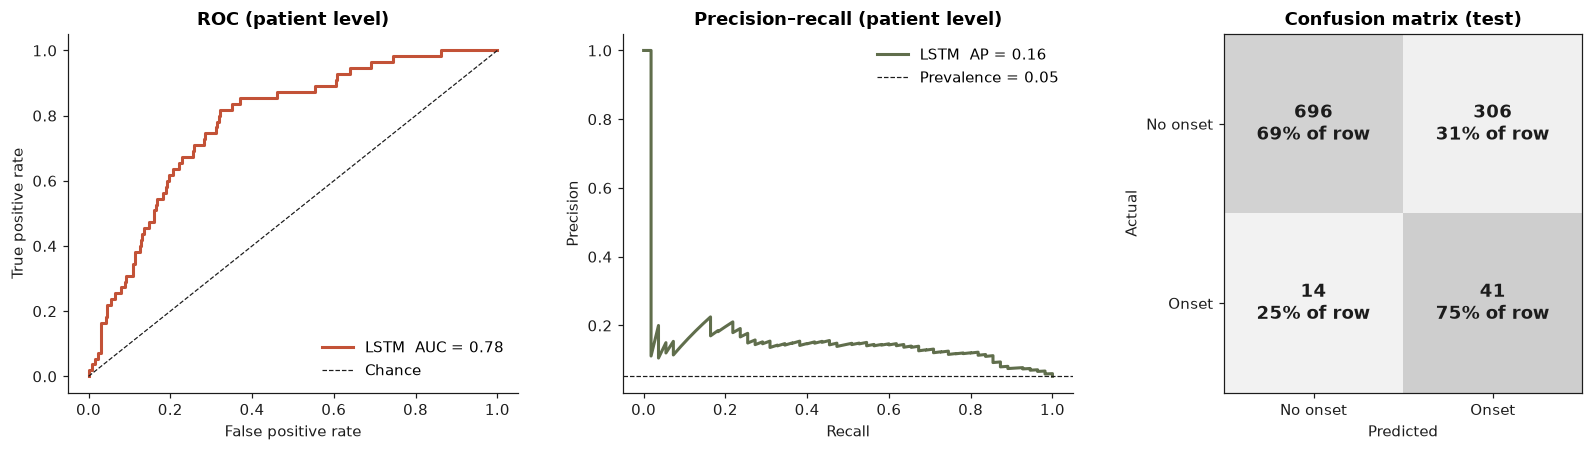

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
y_true = test["y_pat"]

fpr, tpr, _ = roc_curve(y_true, score_test)
axes[0].plot(fpr, tpr, color=TERRACOTTA, lw=2, label=f"LSTM  AUC = {patient_metrics['roc_auc']:.2f}")
axes[0].plot([0, 1], [0, 1], color=INK, lw=0.8, ls="--", label="Chance")
axes[0].set(title="ROC (patient level)", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(frameon=False, loc="lower right")

prec, rec, _ = precision_recall_curve(y_true, score_test)
axes[1].plot(rec, prec, color=OLIVE, lw=2, label=f"LSTM  AP = {patient_metrics['pr_auc']:.2f}")
axes[1].axhline(patient_metrics["prevalence"], color=INK, lw=0.8, ls="--",
                label=f"Prevalence = {patient_metrics['prevalence']:.2f}")
axes[1].set(title="Precision–recall (patient level)", xlabel="Recall", ylabel="Precision")
axes[1].legend(frameon=False)

cm = np.array(patient_metrics["confusion"])
cm_rate = cm / cm.sum(axis=1, keepdims=True)
axes[2].imshow(cm_rate, cmap="Greys", vmin=0, vmax=2.5)
for (i, j), v in np.ndenumerate(cm):
    axes[2].text(j, i, f"{v:,}\n{cm_rate[i, j]:.0%} of row", ha="center", va="center",
                 fontsize=12, fontweight="bold", color=INK)
axes[2].set(title="Confusion matrix (test)", xticks=[0, 1], yticks=[0, 1],
            xticklabels=["No onset", "Onset"], yticklabels=["No onset", "Onset"],
            xlabel="Predicted", ylabel="Actual")
for side in ["top", "right"]:
    axes[2].spines[side].set_visible(True)

fig.tight_layout(); save(fig, "evaluation"); plt.show()

## 5. Lead time: how early does the model flag converters?

For each converter in the test set, lead time is the number of days between the first visit whose risk crosses the threshold and the recorded diagnosis date. Only visits on or before diagnosis are considered. A lead time of 0 means the model only flagged the patient at the diagnosis visit itself.

In [10]:
records = []
for i, pid in enumerate(test["ids"]):
    if test["y_pat"][i] != 1:
        continue
    T = test["valid"][i].sum()
    dates = pd.to_datetime(test["dates"][i])
    flags = (p_test[i, :T] >= threshold) & (dates <= test["diag"][i])
    if flags.any():
        lead = (test["diag"][i] - dates[np.argmax(flags)]).days
    else:
        lead = np.nan   # never flagged
    records.append({"lead_days": lead, "subgroup": grouped[pid]["asian_subgroup"].iat[0]})
lead = pd.DataFrame(records)

flagged = lead.dropna()
lead_summary = {
    "converters": int(len(lead)),
    "flagged": int(len(flagged)),
    "flagged_before_diagnosis": int((flagged.lead_days > 0).sum()),
    "median_days": float(flagged.lead_days.median()) if len(flagged) else None,
    "iqr_days": [float(flagged.lead_days.quantile(q)) for q in (0.25, 0.75)] if len(flagged) else None,
}
print(json.dumps(lead_summary, indent=2))

{
  "converters": 55,
  "flagged": 41,
  "flagged_before_diagnosis": 26,
  "median_days": 265.0,
  "iqr_days": [
    0.0,
    493.0
  ]
}


Subgroup panel omitted: fewer than two subgroups have ≥ 11 flagged converters.


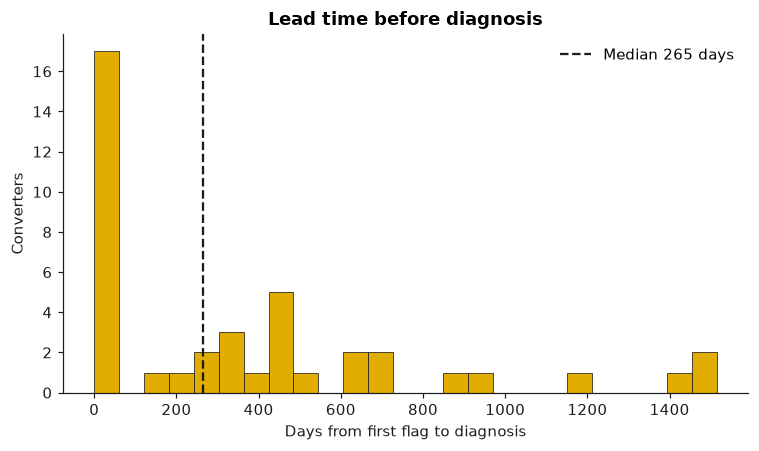

In [11]:
counts = flagged.groupby("subgroup").size()
shown = counts[counts >= MIN_CELL].index
n_panels = 2 if len(shown) >= 2 else 1
fig, axes = plt.subplots(1, n_panels, figsize=(13 if n_panels == 2 else 7, 4.2), squeeze=False)
axes = axes[0]

axes[0].hist(flagged.lead_days, bins=25, color=MUSTARD, edgecolor=INK, linewidth=0.5)
if len(flagged):
    axes[0].axvline(flagged.lead_days.median(), color=INK, lw=1.5, ls="--",
                    label=f"Median {flagged.lead_days.median():.0f} days")
    axes[0].legend(frameon=False)
axes[0].set(title="Lead time before diagnosis", xlabel="Days from first flag to diagnosis",
            ylabel="Converters")
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

if n_panels == 2:
    groups = [flagged.loc[flagged.subgroup == g, "lead_days"] for g in shown]
    bp = axes[1].boxplot(groups, orientation="horizontal", patch_artist=True, showfliers=False,
                         widths=0.55, medianprops={"color": TERRACOTTA, "lw": 2})
    for box in bp["boxes"]:
        box.set(facecolor=STONE, edgecolor=INK)
    axes[1].set_yticks(range(1, len(shown) + 1), [f"{g}  (n={counts[g]})" for g in shown])
    axes[1].set(title=f"Lead time by subgroup (groups with n ≥ {MIN_CELL})", xlabel="Days")
else:
    print(f"Subgroup panel omitted: fewer than two subgroups have ≥ {MIN_CELL} flagged converters.")

fig.tight_layout(); save(fig, "lead_time"); plt.show()

## 6. Which inputs matter?

Permutation importance: shuffle one input across test patients, re-score, and measure the **drop in patient-level ROC-AUC**, averaged over 5 repeats. Dynamic features are shuffled across all real visits (padding is left in place). The subgroup one-hot columns are shuffled together as one block.

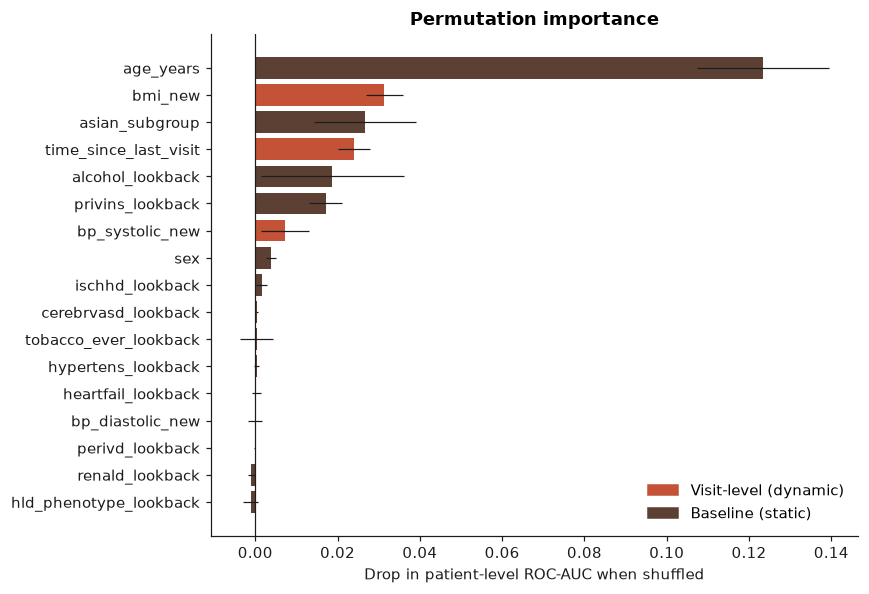

In [12]:
def score_auc(X_dyn, X_stat):
    p = model.predict([X_dyn, X_stat], verbose=0)[..., 0]
    return roc_auc_score(test["y_pat"], np.where(test["valid"], p, -np.inf).max(axis=1))

base_auc = score_auc(test["X_dyn"], test["X_stat"])
rng = np.random.default_rng(SEED)
sub_cols = [i for i, n in enumerate(STATIC_NAMES) if n.startswith("subgroup_")]
features = ([("dyn", [j], f) for j, f in enumerate(DYNAMIC)]
            + [("stat", [i], n) for i, n in enumerate(STATIC_NAMES) if i not in sub_cols]
            + [("stat", sub_cols, "asian_subgroup")])

rows = []
for kind, cols, name in features:
    drops = []
    for _ in range(5):
        Xd, Xs = test["X_dyn"].copy(), test["X_stat"].copy()
        if kind == "dyn":
            vals = Xd[..., cols[0]][test["valid"]]
            Xd[..., cols[0]][test["valid"]] = rng.permutation(vals)
        else:
            Xs[:, cols] = Xs[rng.permutation(len(Xs))][:, cols]
        drops.append(base_auc - score_auc(Xd, Xs))
    rows.append({"feature": name, "auc_drop": np.mean(drops), "sd": np.std(drops)})
importance = pd.DataFrame(rows).sort_values("auc_drop")

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [TERRACOTTA if f in DYNAMIC else TEAK for f in importance.feature]
ax.barh(importance.feature, importance.auc_drop, xerr=importance.sd, color=colors,
        error_kw={"ecolor": INK, "lw": 0.8})
ax.axvline(0, color=INK, lw=0.8)
ax.set(title="Permutation importance", xlabel="Drop in patient-level ROC-AUC when shuffled")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=TERRACOTTA), plt.Rectangle((0, 0), 1, 1, color=TEAK)],
          labels=["Visit-level (dynamic)", "Baseline (static)"], frameon=False, loc="lower right")
fig.tight_layout(); save(fig, "feature_importance"); plt.show()

## 7. Save results

Only aggregate numbers are written. No patient identifiers, dates or row-level predictions leave this notebook.

In [13]:
results = {
    "data": Path(DATA_PATH).name,
    "threshold": threshold,
    "patient_level": patient_metrics,
    "visit_level": visit_metrics,
    "lead_time": lead_summary,
    "importance": importance.sort_values("auc_drop", ascending=False)
                            .round(4).to_dict(orient="records"),
}
(RESULTS_DIR / "metrics.json").write_text(json.dumps(results, indent=2, default=float))
print(f"Saved {RESULTS_DIR / 'metrics.json'} and figures in {FIG_DIR}/")

Saved ../results/metrics.json and figures in ../figures/


## Limitations

* **Single health system.** All patients come from one NYC academic health system; external validation is needed before any claim of generalisability.
* **Vitals only.** The model sees BP, BMI and visit timing but no labs (A1c, glucose), which caps performance and is a deliberate choice to test what routine vitals alone can do.
* **Diagnosis date is a proxy.** `surv_no_pheno` reflects when diabetes was first recorded, not true biological onset, so lead time is measured against documentation.
* **Single imputation.** The first MICE dataset is used; pooling across all 5 imputations would propagate imputation uncertainty.
* **Small subgroups.** Some Asian subgroups have few converters, so subgroup lead-time estimates are imprecise and groups with n < 11 are suppressed.